
# Phoneme Variability in Speech BCI Neural Dynamics
### GPFA latent trajectories × multidimensional Dynamic Time Warping

**Brain–Computer Interface Hackathon — UC San Diego (Data Science & Neuroscience) × University of Michigan (BME), Fall 2025**
🥈 **2nd Place — Best Engineering** · Team *Jawdroppers*

---

**Question.** Intracortical speech BCIs decode attempted speech from motor-cortex spiking activity. When a participant attempts the *same* phoneme many times, how consistent is the underlying neural activity — and which phonemes are the least consistent? Phonemes with high trial-to-trial variability are natural candidates for decoder confusion, so quantifying this variability points to where decoders, training data, and augmentation should focus.

**Data.** Intracortical recordings from participant T12 attempting to speak 39 English phonemes plus a silent `DO_NOTHING` control (460 trials, session 2022‑04‑21), from the dataset behind [Willett et al., *Nature* 2023](https://www.nature.com/articles/s41586-023-06377-x). Each trial is represented by a **32‑dimensional GPFA latent trajectory** over time.

**Pipeline.**
1. **GPFA latent trajectories** — smooth, low-dimensional summaries of population spiking for every trial.
2. **Multidimensional DTW** — pairwise distances between all trials of each phoneme across all 32 latent dimensions, giving one trial × trial similarity matrix per phoneme.
3. **Hierarchical clustering** of each matrix to reveal sub-groups and outlier trials.
4. **DTW temporal alignment** to a medoid reference trial, separating *timing* variability (speaking faster/slower) from *shape* variability.
5. **Variability maps** (phoneme × latent dimension) before and after alignment.

**Key findings** (details in each section):
- The silent `DO_NOTHING` control has the lowest mean DTW distance (≈163), a sanity check that attempted speech adds structured variability; `kIt` is the most consistent phoneme, essentially at baseline. **/f/ (`Fah`) is the most variable** (≈228, ~40% above baseline), followed by `Wah`, `chOIce`, `Mah` and `Zah`.
- `Fah` also has the highest trial-to-trial spread in the leading GPFA dimension — two independent metrics agree.
- Variability is concentrated in the **first few GPFA dimensions** and decays quickly with dimension index, so a handful of latent dimensions carry most of the phoneme-specific variability.
- Clustered DTW matrices expose **individual outlier trials** (e.g. in `trAp`, `Wah`, `Fah`) — useful for data-quality screening before decoder training.


## 1. Setup

In [ ]:
!pip install -q dtw-python

In [ ]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform
from dtw import dtw, warp

plt.rcParams["figure.dpi"] = 100


## 2. Load the data
The hackathon dataset is hosted publicly on Google Cloud Storage, so the notebook downloads only the files it needs (no Google Drive required). `gpfaFactor.pkl` holds one `(32 latent dims × T time bins)` array per trial; `cueText.npy` holds the phoneme cue for each trial.


In [ ]:
BASE_URL = "https://storage.googleapis.com/beyond_speech_dataset1/t12.2022.04.21_phonemes/train"
baseDir = "./data/"
os.makedirs(baseDir, exist_ok=True)

for f in ["cueText.npy", "gpfaFactor.pkl", "gpfaRate.pkl"]:
    if not os.path.exists(baseDir + f):
        os.system(f"wget -q {BASE_URL}/{f} -O {baseDir + f}")

In [ ]:
gpfaFactor_train = pd.read_pickle(baseDir + "gpfaFactor.pkl")   # per trial: (32 latent dims, T)
gpfaRate_train   = pd.read_pickle(baseDir + "gpfaRate.pkl")     # per trial: GPFA-smoothed firing rates
cueText_train    = np.load(baseDir + "cueText.npy", allow_pickle=True)

unique_phonemes = sorted(set(cueText_train))
lengths = [trial.shape[1] for trial in gpfaFactor_train]
counts = pd.Series(cueText_train).value_counts()

print(f"{len(gpfaFactor_train)} trials | {len(unique_phonemes)} cues | "
      f"{gpfaFactor_train[0].shape[0]} GPFA latent dims")
print(f"trial length: {min(lengths)}–{max(lengths)} time bins")
print(f"trials per cue: {counts.min()}–{counts.max()}")

In [ ]:
def get_phoneme_trials(phoneme, mode="factor"):
    # Return every trial of `phoneme` as a (dims, T) array.
    # mode="factor" -> 32-dim GPFA latents; mode="rate" -> smoothed firing rates (channels, T)
    indexes = [i for i, cue in enumerate(cueText_train) if cue == phoneme]
    if mode == "factor":
        return [gpfaFactor_train[idx] for idx in indexes]
    elif mode == "rate":
        return [gpfaRate_train[idx].T for idx in indexes]
    raise ValueError("mode must be 'factor' or 'rate'")


## 3. Exploring the neural trajectories
Each grey line is one attempt; red is the across-trial mean. Even for a single channel or latent dimension, trials of the same phoneme vary in both **amplitude** and **timing**.


In [ ]:
def plot_firing_rates(cue, channels=range(5)):
    # Smoothed firing rate for a few channels, all trials of one phoneme
    trials = get_phoneme_trials(cue, mode="rate")
    channels = list(channels)
    fig, axs = plt.subplots(1, len(channels), figsize=(4 * len(channels), 2.8))
    for ax, ch in zip(axs, channels):
        trajs = [trial[ch] for trial in trials]
        min_len = min(len(t) for t in trajs)
        trimmed = [t[:min_len] for t in trajs]
        for t in trimmed:
            ax.plot(t, color="gray", alpha=0.3)
        ax.plot(np.mean(trimmed, axis=0), color="red")
        ax.set_title(f"Ch {ch}")
        ax.set_xticks([]); ax.set_yticks([])
    plt.suptitle(f"Firing rates — {cue}")
    plt.tight_layout()
    plt.show()

for cue in ["Bah", "Fah", "DO_NOTHING"]:
    plot_firing_rates(cue)

In [ ]:
def plot_single_latent_dimension_across_phonemes(latent_dim_to_plot=0):
    phoneme_list = unique_phonemes
    num_phonemes = len(phoneme_list)

    # Define grid dimensions (e.g., 5 rows, 8 columns for 40 phonemes)
    num_cols = 8
    num_rows = (num_phonemes + num_cols - 1) // num_cols # Ensures enough rows for all phonemes

    fig, axs = plt.subplots(num_rows, num_cols, figsize=(num_cols * 3.5, num_rows * 2.8))
    axs = axs.flatten()

    for i, phoneme_name in enumerate(phoneme_list):
        if i >= len(axs): # Safety break if more phonemes than subplots
            print(f"Warning: Not enough subplots to display all {num_phonemes} phonemes. Stopping at {i} phonemes.")
            break

        ax = axs[i]

        trials = get_phoneme_trials(phoneme_name)

        all_trajs_for_dim = [trial[latent_dim_to_plot] for trial in trials]

        min_len_for_this_phoneme = np.min([len(t) for t in all_trajs_for_dim])
        trimmed_trajs = [t[:min_len_for_this_phoneme] for t in all_trajs_for_dim]

        for traj_data in trimmed_trajs:
            ax.plot(traj_data, color='gray', alpha=0.6, linewidth=0.8)

        mean_trajectory = np.mean(trimmed_trajs, axis=0)
        ax.plot(mean_trajectory, color='red', linewidth=2.5, label='Mean')

        ax.set_title(f'{phoneme_name}')

        if i % num_cols == 0: # Leftmost column
            ax.set_ylabel(f'Latent Dim {latent_dim_to_plot} Value')
        else:
            ax.set_ylabel('')

        if i >= num_phonemes - num_cols: # Bottommost row
            ax.set_xlabel('Time (bins)')
        else:
            ax.set_xlabel('')

        ax.set_xticks([])
        ax.set_yticks([])

    for j in range(i + 1, len(axs)):
        fig.delaxes(axs[j])

    plt.suptitle(f'Individual Trial Trajectories for Latent Dimension {latent_dim_to_plot} Across All Phonemes', fontsize=18, y=1.02)
    plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to make space for suptitle
    plt.show()

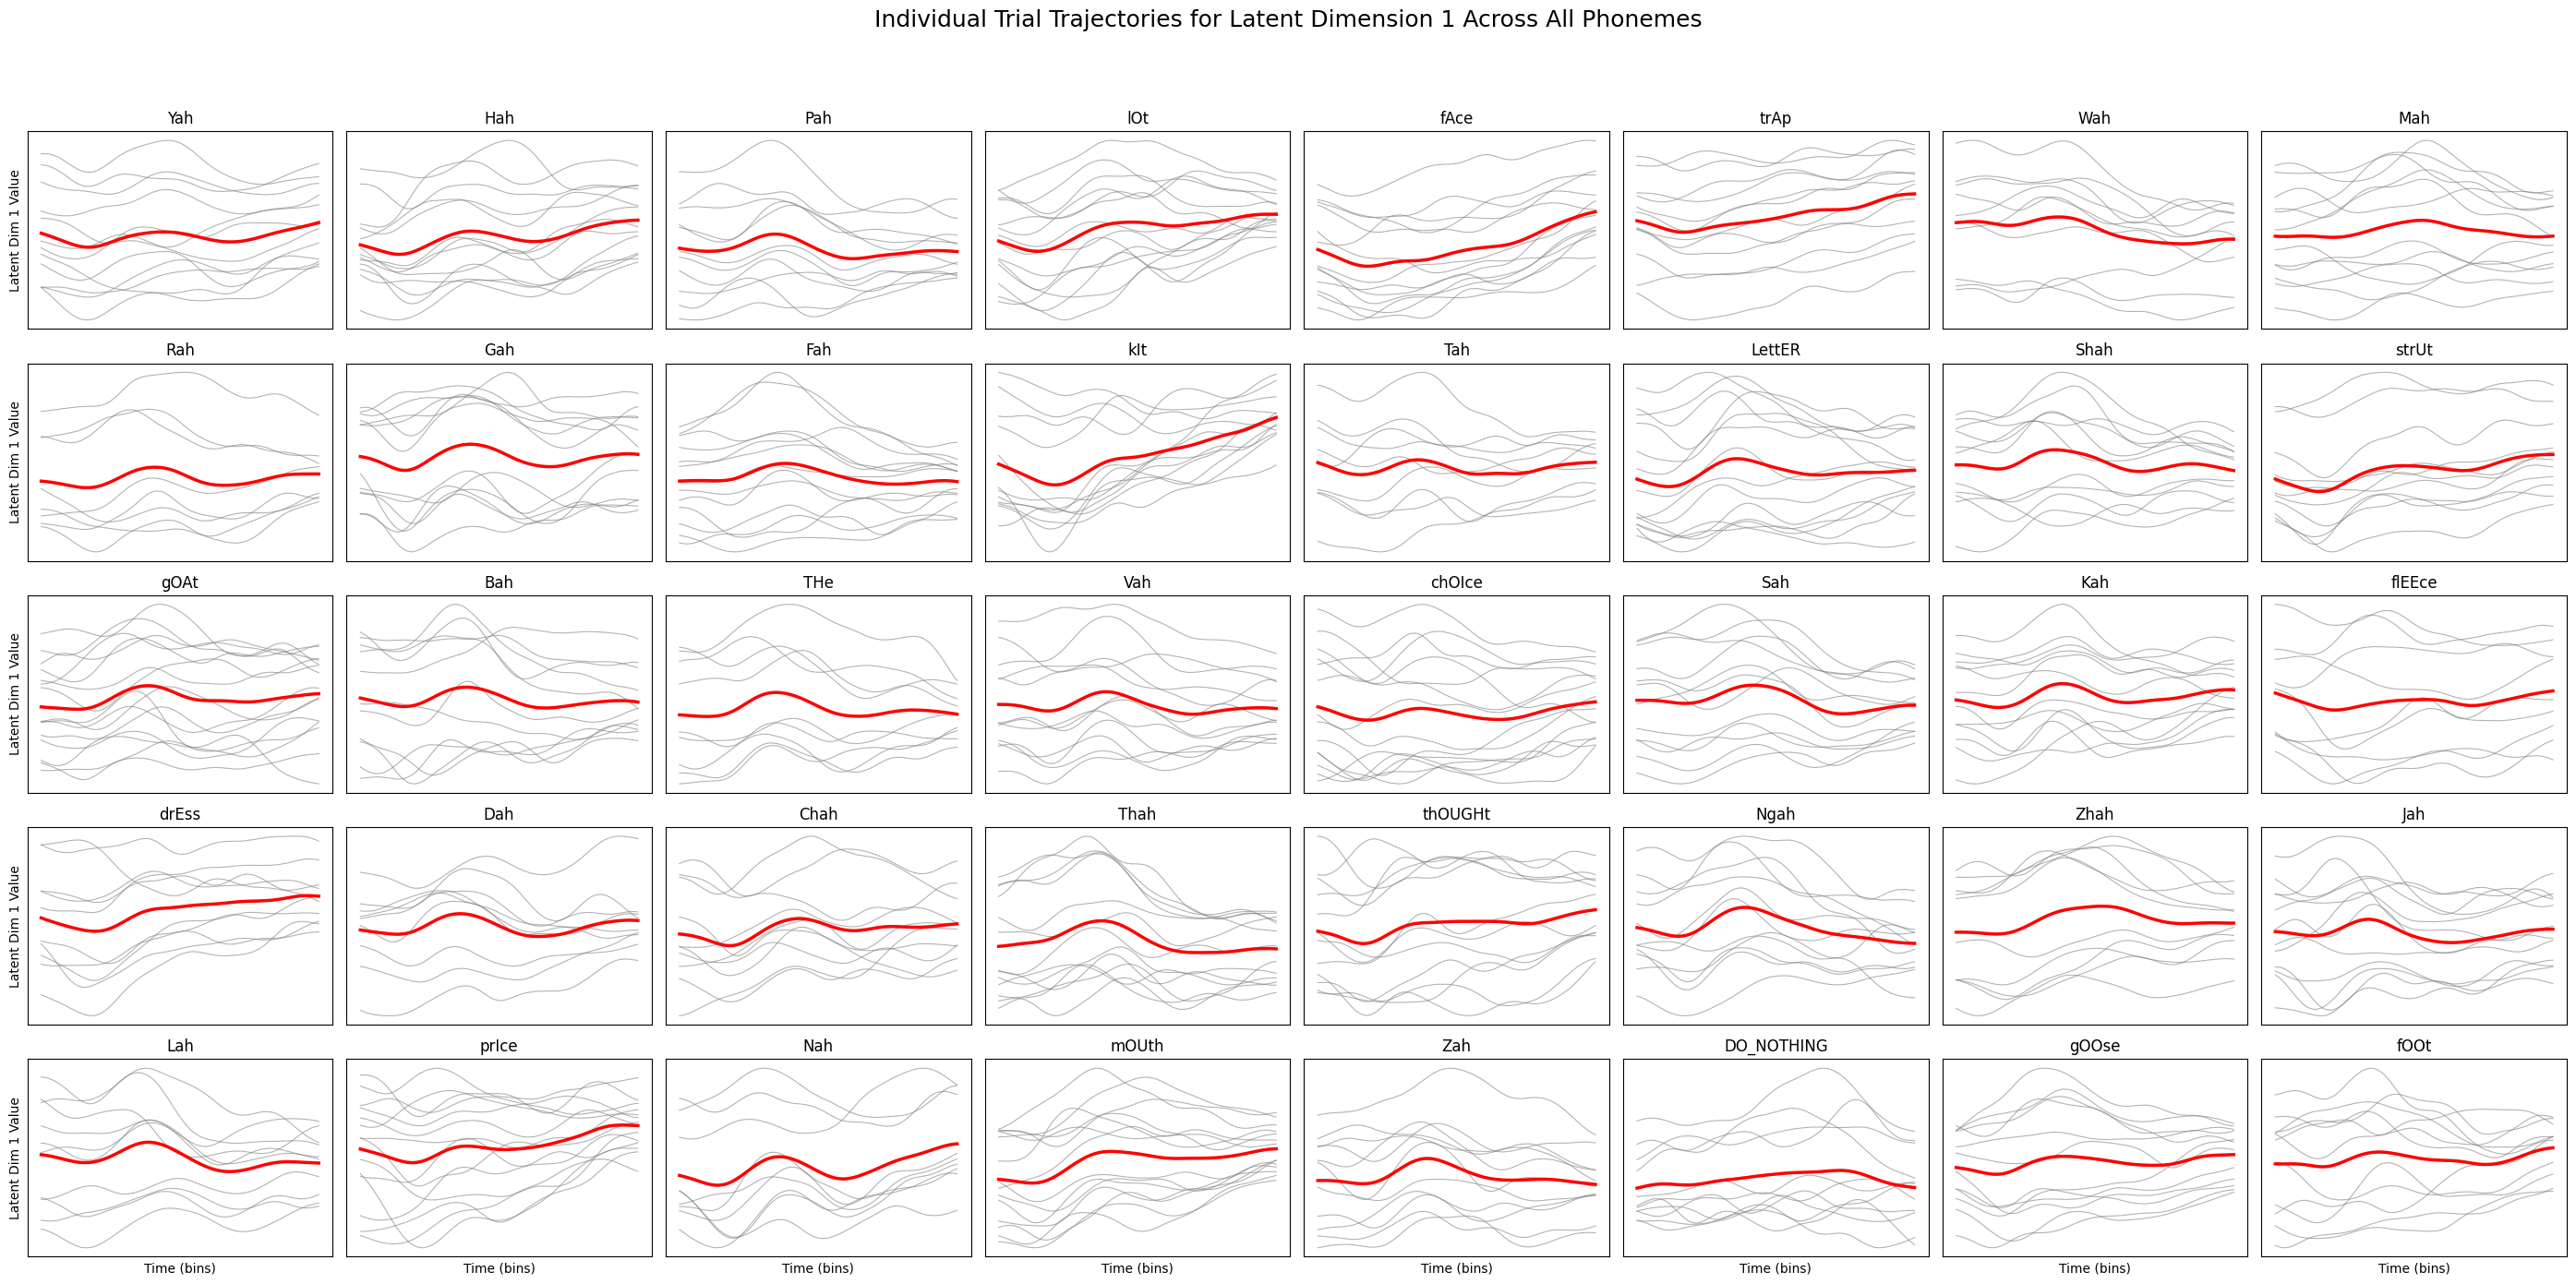

In [ ]:
plot_single_latent_dimension_across_phonemes(latent_dim_to_plot=1)


All 32 latent dimensions for one phoneme (`Bah`), every trial overlaid:


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_original_gpfa_latents(phoneme, rows=8, cols=4):
    """
    Plot original (unwarped) GPFA latent dimensions for a given phoneme.
    Assumes get_phoneme_trials(phoneme) -> list of arrays, each with 32 latent dims.
    Each subplot: one latent dimension, overlaid across all trials for that phoneme.
    """

    trials = get_phoneme_trials(phoneme)  # list of trial arrays
    if len(trials) == 0:
        print(f"No trials found for phoneme '{phoneme}'")
        return

    # Infer shape convention: (32, T) vs (T, 32)
    example = trials[0]
    if example.shape[0] == 32:
        # shape: (latent_dim, time)
        def get_curve(trial, dim_idx):
            return trial[dim_idx, :]
        T = example.shape[1]
    elif example.shape[1] == 32:
        # shape: (time, latent_dim)
        def get_curve(trial, dim_idx):
            return trial[:, dim_idx]
        T = example.shape[0]
    else:
        raise ValueError(
            f"Unexpected trial shape {example.shape}. "
            "Expected either (32, T) or (T, 32)."
        )

    num_dims = 32
    time_bins = np.arange(T)

    fig, ax = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 2.8))

    for dim in range(num_dims):
        r = dim // cols
        c = dim % cols

        # Overlay all trials for this latent dimension
        for trial in trials:
            curve = get_curve(trial, dim)
            # handle slight length differences across trials, if any
            t = np.arange(len(curve))
            ax[r, c].plot(t, curve, alpha=0.6)

        ax[r, c].set_title(f"\"{phoneme}\" latent dim {dim} (original)")
        ax[r, c].set_xlabel("Time (bins)")
        ax[r, c].set_ylabel(f"Latent value (dim {dim})")

    plt.tight_layout()
    plt.show()

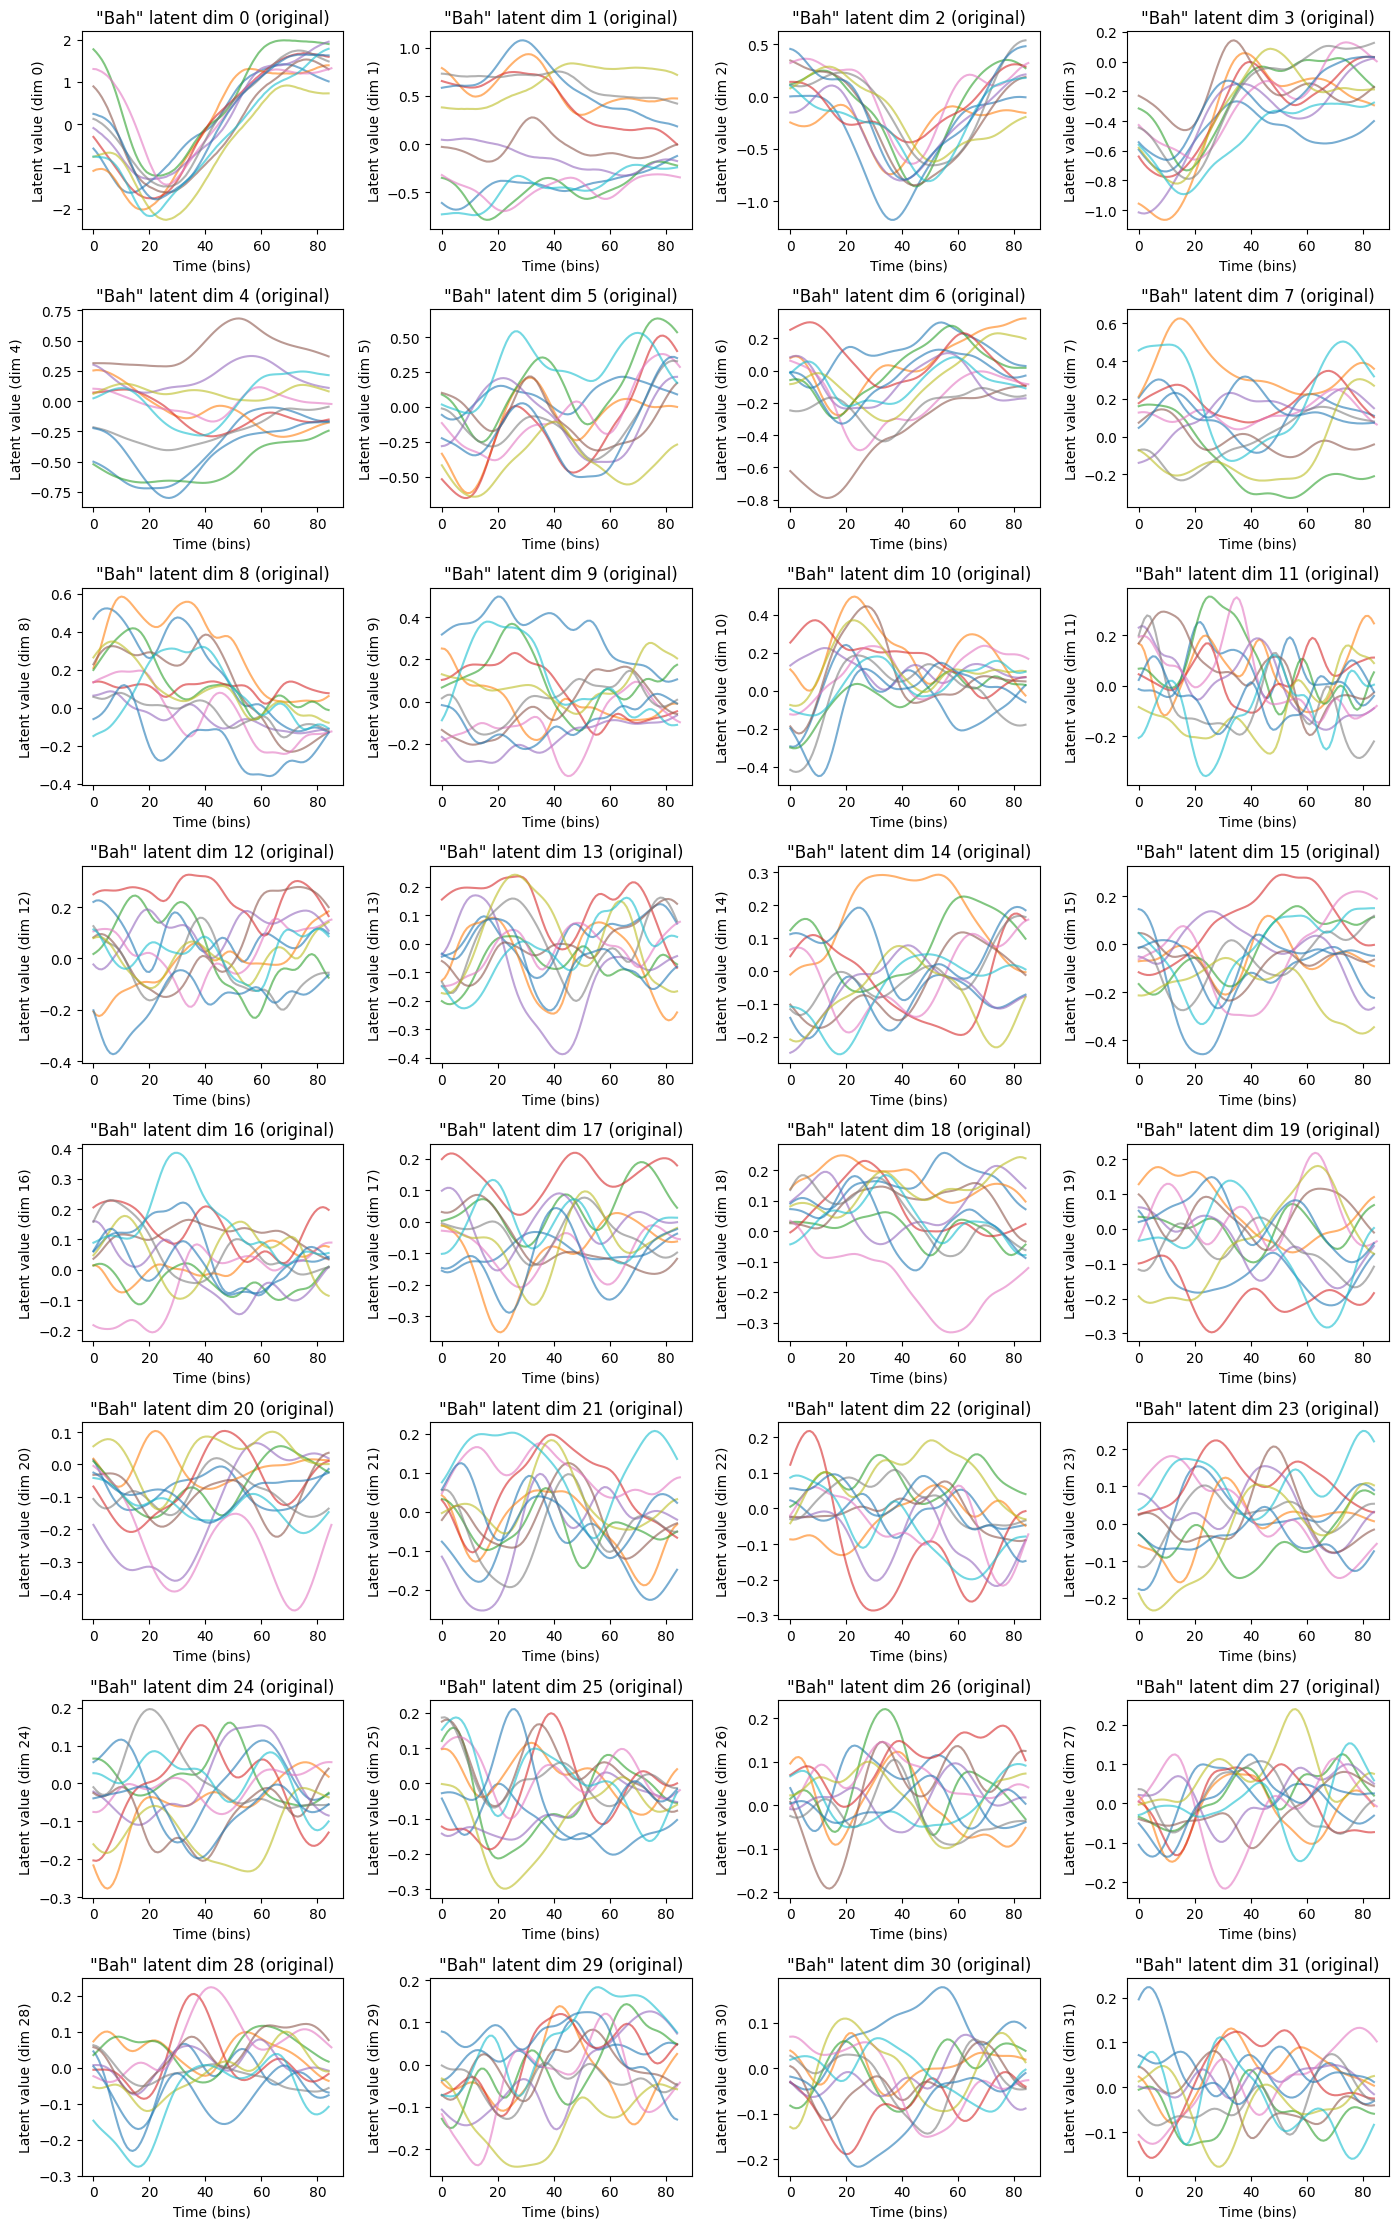

In [ ]:
plot_original_gpfa_latents("Bah")


## 4. Trial-to-trial similarity with multidimensional DTW
Trials differ in length and speaking speed, so a point-by-point (Euclidean) comparison would mostly measure misalignment. **Dynamic Time Warping** finds the optimal non-linear time alignment between two multivariate time series and returns the residual distance. Here every pair of trials of a phoneme is compared using all 32 GPFA dimensions at once (Euclidean local cost), giving one symmetric `n_trials × n_trials` distance matrix per phoneme.


In [ ]:
def create_dtw_matrix(trials_list):
    # Pairwise multidimensional DTW distance between all trials (each trial: (32, T))
    series = [trial.T for trial in trials_list]          # -> (T, 32) for dtw-python
    n = len(series)
    D = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            d = dtw(series[i], series[j], dist_method="euclidean", distance_only=True).distance
            D[i, j] = D[j, i] = d
    return D

dtw_matrices = {p: create_dtw_matrix(get_phoneme_trials(p)) for p in unique_phonemes}


Each matrix is reordered by **average-linkage hierarchical clustering** on the DTW distances, so groups of mutually similar trials form blocks and outlier trials appear as bright rows/columns. All panels share one colour scale (dark = similar).


In [ ]:
def plot_all_dtw_matrices(dtw_matrices, ncols=5):
    names = list(dtw_matrices)
    nrows = int(np.ceil(len(names) / ncols))
    vmax = max(D.max() for D in dtw_matrices.values())
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
    axes = axes.flatten()
    for ax, p in zip(axes, names):
        D = dtw_matrices[p]
        if D.shape[0] > 2:
            order = leaves_list(linkage(squareform(D, checks=False), method="average"))
            D = D[order][:, order]
        sns.heatmap(D, cmap="viridis", square=True, ax=ax, cbar=False, vmin=0, vmax=vmax)
        ax.invert_yaxis()
        ax.set_title(p, fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])
    for ax in axes[len(names):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()

plot_all_dtw_matrices(dtw_matrices)


### Which phonemes are least consistent?
Mean pairwise DTW distance per phoneme (higher = less consistent neural trajectory across attempts). The silent `DO_NOTHING` cue is the natural baseline.


In [ ]:
avg_dtw = pd.Series({p: np.mean(D) for p, D in dtw_matrices.items()}).sort_values()

colors = ["#d62728" if p == "DO_NOTHING" else "#4c72b0" for p in avg_dtw.index]
plt.figure(figsize=(8, 10))
plt.barh(avg_dtw.index, avg_dtw.values, color=colors)
plt.axvline(avg_dtw["DO_NOTHING"], color="#d62728", ls="--", lw=1, label="DO_NOTHING baseline")
plt.xlabel("Mean pairwise DTW distance")
plt.title("Trial-to-trial neural variability per phoneme")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print("Most variable :", ", ".join(f"{p} ({v:.0f})" for p, v in avg_dtw[::-1][:5].items()))
print("Least variable:", ", ".join(f"{p} ({v:.0f})" for p, v in avg_dtw[:5].items()))


## 5. Temporal alignment within a latent dimension
DTW distances mix two sources of variability: **timing** (the same trajectory produced faster or slower) and **shape** (a genuinely different trajectory). To separate them, each latent dimension's trials are warped onto a common reference:

1. pick the **DTW medoid** — the trial with the smallest total DTW distance to all others — as the reference;
2. align every trial to it with DTW;
3. resample each trial along its warping path so all trials share the reference's time axis.

Before alignment (`Bah`, latent dim 2), the main dip occurs at different times on different attempts:


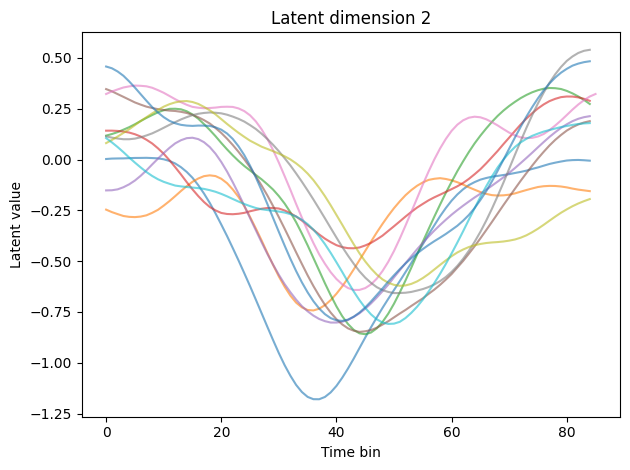

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get only the "Bah" trials (14 of them)
bah_trials = get_phoneme_trials("Bah")   # list of length 14
latent_idx = 2  # latent dimension 1 if using 0-based indexing

temp_trials = get_phoneme_trials("Bah")
temp_transposed_trials = [temp_trial.T for temp_trial in temp_trials]

# Storing the 14 curves in this latent dimension
latent_dimension_curves = []

plt.figure()
for trial in temp_transposed_trials:
    #print(trial.shape)

    curve = trial[:, latent_idx]  # y = latent value

    T = trial.shape[0]
    time_bins = np.arange(T)         # x = time bins (85)

    plt.plot(time_bins, curve, alpha=0.6)    # overlay all 14
    # Appending the current curve into an array
    latent_dimension_curves.append(curve)

plt.xlabel("Time bin")
plt.ylabel("Latent value")
plt.title("Latent dimension 2")
plt.tight_layout()
plt.show()

In [ ]:
def dtw_medoid(curves):
    # Index of the curve with the smallest total DTW distance to all others
    n = len(curves)
    D = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            D[i, j] = D[j, i] = dtw(curves[i], curves[j], distance_only=True).distance
    return int(np.argmin(D.sum(axis=1)))


def align_dimension(phoneme, latent_dim, sigma=2):
    # DTW-align all trials of `phoneme` in one latent dimension to the medoid trial.
    # Returns an (n_trials, T_ref) array of aligned curves (smoothed for display if sigma > 0).
    curves = [trial[latent_dim] for trial in get_phoneme_trials(phoneme)]
    reference = curves[dtw_medoid(curves)]
    aligned = []
    for curve in curves:
        alignment = dtw(curve, reference, dist_method="euclidean")
        wq = warp(alignment, index_reference=False)   # indices into `curve`, one per reference bin
        warped = curve[wq]
        aligned.append(gaussian_filter1d(warped, sigma=sigma) if sigma else warped)
    return np.vstack(aligned)


def plot_aligned_dimension(phoneme, latent_dim):
    raw = [trial[latent_dim] for trial in get_phoneme_trials(phoneme)]
    aligned = align_dimension(phoneme, latent_dim)
    fig, axs = plt.subplots(1, 2, figsize=(11, 3.5), sharey=True)
    for c in raw:
        axs[0].plot(c, alpha=0.6)
    for c in aligned:
        axs[1].plot(c, alpha=0.6)
    axs[0].set_title(f"'{phoneme}' dim {latent_dim} — original")
    axs[1].set_title(f"'{phoneme}' dim {latent_dim} — DTW-aligned to medoid")
    for ax in axs:
        ax.set_xlabel("Time (bins)")
    axs[0].set_ylabel("Latent value")
    plt.tight_layout()
    plt.show()

plot_aligned_dimension("Bah", 2)
plot_aligned_dimension("Bah", 9)

In [ ]:
def plot_aligned_all_dims(phoneme, rows=8, cols=4):
    fig, ax = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 2.4))
    for d, a in enumerate(ax.flatten()):
        for c in align_dimension(phoneme, d):
            a.plot(c, lw=0.9)
        a.set_title(f"'{phoneme}' dim {d} (aligned)", fontsize=9)
        a.set_xticks([])
    plt.tight_layout()
    plt.show()

plot_aligned_all_dims("Bah")


## 6. Variability map: phoneme × latent dimension
For each phoneme and GPFA dimension: the standard deviation across trials at each time bin, averaged over time. Trials are first trimmed to a common length (no alignment).


In [ ]:
phonemes = unique_phonemes
latent_dims = 32

def variability_for_phoneme_and_dim(cue, d):
    trajs = [trial[d] for trial in get_phoneme_trials(cue)]
    min_len = min(len(t) for t in trajs)
    X = np.vstack([t[:min_len] for t in trajs])   # (n_trials, T)
    return X.std(axis=0).mean()                   # mean over time of across-trial STD

variability_matrix = np.array([[variability_for_phoneme_and_dim(p, d) for d in range(latent_dims)]
                               for p in phonemes])

p_idx = phonemes.index("Bah")
plt.plot(variability_matrix[p_idx])
plt.xlabel("Latent dimension"); plt.ylabel("Average STD")
plt.title("Variability across GPFA dims for Bah")
plt.show()

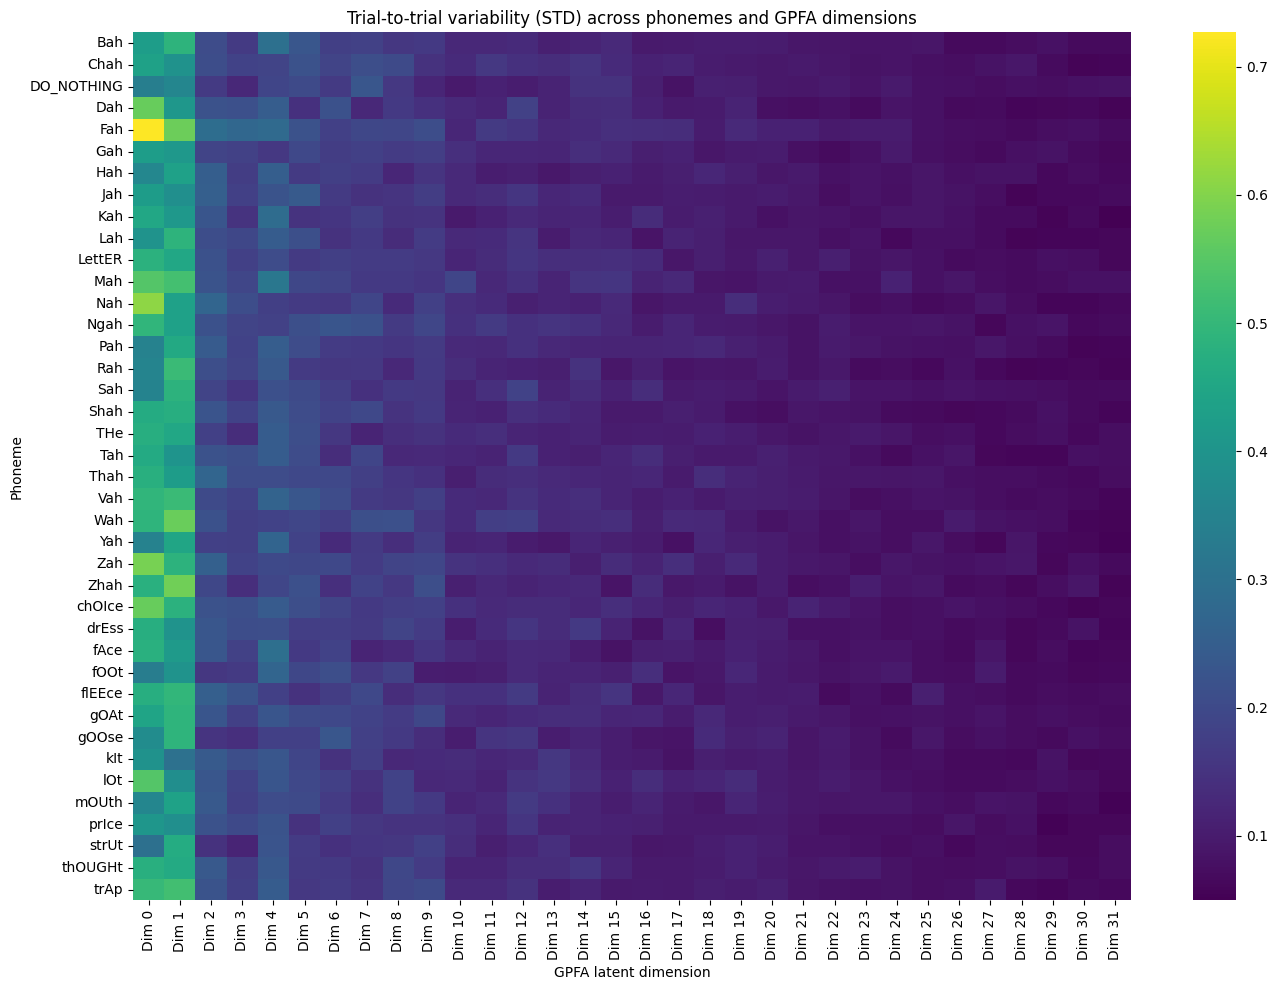

In [ ]:
plt.figure(figsize=(14, 10))
sns.heatmap(
    variability_matrix,
    xticklabels=[f"Dim {i}" for i in range(latent_dims)],
    yticklabels=phonemes,
    cmap="viridis"
)

plt.title("Trial-to-trial variability (STD) across phonemes and GPFA dimensions")
plt.xlabel("GPFA latent dimension")
plt.ylabel("Phoneme")
plt.tight_layout()
plt.show()


Variability is concentrated in the leading GPFA dimensions (0–1, then 4) and decays with dimension index; `Fah` stands out in dimension 0, matching its top rank in the DTW analysis above.

### After DTW alignment: how much variability is just timing?
Repeating the same measure on DTW-aligned trials removes timing differences. The ratio *aligned / unaligned* shows the share of variability that is **not** explained by timing: values near 1 mean the trajectories genuinely differ in shape; low values mean the attempts mostly differed in speed.


In [ ]:
# sigma=0: no smoothing, so aligned and unaligned STDs are directly comparable
aligned_variability = np.array([[align_dimension(p, d, sigma=0).std(axis=0).mean() for d in range(latent_dims)]
                                for p in phonemes])
shape_fraction = aligned_variability / variability_matrix

fig, axs = plt.subplots(1, 2, figsize=(20, 10), sharey=True)
sns.heatmap(aligned_variability, ax=axs[0], cmap="viridis", yticklabels=phonemes,
            xticklabels=[f"Dim {i}" for i in range(latent_dims)])
axs[0].set_title("Trial-to-trial STD after DTW alignment")
sns.heatmap(shape_fraction, ax=axs[1], cmap="magma", vmin=0, vmax=1,
            xticklabels=[f"Dim {i}" for i in range(latent_dims)])
axs[1].set_title("Aligned / unaligned STD  (share not explained by timing)")
for ax in axs:
    ax.set_xlabel("GPFA latent dimension")
plt.tight_layout()
plt.show()

summary = pd.DataFrame({
    "unaligned_std (dims 0-4)": variability_matrix[:, :5].mean(axis=1),
    "aligned_std (dims 0-4)": aligned_variability[:, :5].mean(axis=1),
}, index=phonemes)
summary["share_not_timing"] = summary.iloc[:, 1] / summary.iloc[:, 0]
summary.sort_values("unaligned_std (dims 0-4)", ascending=False).round(3).head(10)


## 7. Takeaways for speech decoders
- **Variability is phoneme-specific.** Attempted phonemes span a wide range of trial-to-trial consistency (from `kIt`, at the silent baseline, to `Fah`, ~40% above it); `Fah`, `Wah`, `chOIce`, `Mah` and `Zah` are the least consistent. These are the phonemes a decoder is most likely to confuse, and the ones that would benefit most from extra training trials or targeted data augmentation.
- **A few latent dimensions dominate.** Most variability lives in the leading GPFA dimensions, supporting compact low-dimensional decoder inputs and dimension-specific regularisation.
- **Timing vs. shape.** DTW alignment separates speaking-rate differences (which time-warping-tolerant decoders such as RNN/CTC models can absorb) from genuine trajectory differences (which they cannot).
- **Outlier trials.** Clustered DTW matrices flag individual atypical attempts, a cheap screen for noisy training data.

**Next steps:** relate per-phoneme variability to per-phoneme decoder error (confusion matrix) on the held-out test split; use DTW-aligned templates as augmentation; extend the analysis to the 50-word dataset and across recording sessions.

### References
- Willett, F. R. *et al.* A high-performance speech neuroprosthesis. *Nature* **620**, 1031–1036 (2023).
- Yu, B. M. *et al.* Gaussian-process factor analysis for low-dimensional single-trial analysis of neural population activity. *J. Neurophysiol.* **102**, 614–635 (2009).
- Giorgino, T. Computing and visualizing dynamic time warping alignments in R: the dtw package. *J. Stat. Softw.* **31**(7) (2009).
